In [ ]:
import subprocess, sys, datetime
packages = ["requests", "cartopy"]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

In [ ]:
import requests
from io import BytesIO

input_date = input('Enter date (DD/MM/YYYY): ')
input_hour = input('Enter hour (HH): ')
day, month, year = input_date.split('/')

url = f'https://deepmind.google.com/science/weatherlab/download/cyclones/FNV3/ensemble/paired/atcf/FNV3_{year}_{month.zfill(2)}_{day.zfill(2)}T{input_hour.zfill(2)}_00_atcf_a_deck.txt'

response = requests.get(url)
if response.status_code == 200:
  adeck_file = response.content
  print('File downloaded successfully.')
else:
  print(f'Error downloading file: Status Code {response.status_code}')

btk = input('Enter ATCF storm ID: ').upper()
basin, btk_id = btk[:2], btk[2:]


Enter date (DD/MM/YYYY): 12/12/2025
Enter hour (HH): 18
File downloaded successfully.
Enter ATCF storm ID: io07


In [ ]:
if 'adeck_file' in locals() and adeck_file:
  # Assuming the file is text-based, decode it to a string
  try:
    file_content_str = adeck_file.decode('utf-8')
    print('First 1000 characters of the file content:')
    print(file_content_str[:1000])
  except UnicodeDecodeError:
    print('Could not decode file content as UTF-8. Displaying raw bytes (first 1000):')
    print(adeck_file[:1000])
else:
  print('No file content available to display. Please ensure the download was successful.')


First 1000 characters of the file content:
# If this file contains data that relates to a time no more than 48 hours ago,
# BY USING IT YOU AGREE TO THE LEGALLY BINDING TERMS OF USE FOUND AT
#   https://storage.googleapis.com/weathernext-public/terms-of-use.pdf
# Any data that relates to a time more than 48 hours ago is licensed under the
# Creative Commons Attribution International License, Version 4.0 (CC BY 4.0).
# BEGIN DATA
IO, 07, 2025121218, 03, F000,   0,  86S,  953E,  45,  999, XX,  34, NEQ,   30,   60,   50,   30,     ,     ,  25,
IO, 07, 2025121218, 03, F000,   6,  88S,  950E,  39,  999, XX,  34, NEQ,    0,    0,   11,    0,     ,     ,  11,
IO, 07, 2025121218, 03, F000,  12,  89S,  944E,  39, 1000, XX,  34, NEQ,    8,   13,    7,    4,     ,     ,  13,
IO, 07, 2025121218, 03, F000,  18,  94S,  933E,  47,  989, XX,  34, NEQ,   56,   61,   52,   48,     ,     ,  19,
IO, 07, 2025121218, 03, F000,  24,  97S,  927E,  34,  998, XX,  34, NEQ,   12,   26,    7,    8,     ,     ,  2

In [ ]:
start_data_marker = '# BEGIN DATA'
start_index = file_content_str.find(start_data_marker)

parsed_data = []

if start_index != -1:
    # Get the string after '# BEGIN DATA' and split into lines
    data_lines_str = file_content_str[start_index + len(start_data_marker):]
    data_lines = data_lines_str.strip().split('\n')

    # Iterate through each data line and extract the required information
    for line in data_lines:
        if not line.strip():  # Skip empty lines
            continue

        # Split by comma, handling potential extra spaces
        fields = [field.strip() for field in line.split(',')]

        # Ensure there are enough fields to prevent IndexError
        if len(fields) >= 9: # Check for at least index 8 (wind speed)
            storm_basin = fields[0]
            storm_number = fields[1]
            ensemble_identifier = fields[4] # e.g., 'F000'
            latitude = fields[6]            # e.g., '84S'
            longitude = fields[7]           # e.g., '973E'
            wind_speed = fields[8]          # e.g., '35'

            parsed_data.append({
                'storm_basin': storm_basin,
                'storm_number': storm_number,
                'ensemble_identifier': ensemble_identifier,
                'latitude': latitude,
                'longitude': longitude,
                'wind_speed': wind_speed
            })

print(f"Extracted {len(parsed_data)} data points.")
print("First 5 extracted data points:")
for i in range(min(5, len(parsed_data))):
    print(parsed_data[i])

Extracted 1108 data points.
First 5 extracted data points:
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': '86S', 'longitude': '953E', 'wind_speed': '45'}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': '88S', 'longitude': '950E', 'wind_speed': '39'}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': '89S', 'longitude': '944E', 'wind_speed': '39'}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': '94S', 'longitude': '933E', 'wind_speed': '47'}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': '97S', 'longitude': '927E', 'wind_speed': '34'}


In [ ]:
def convert_coords(coord_str):
    coord_str = coord_str.strip()
    if not coord_str:
        return None

    try:
        # Extract the numeric part and direction
        if coord_str[-1] in ('N', 'S', 'E', 'W'):
            direction = coord_str[-1]
            value = float(coord_str[:-1])/10
        else:
            # Assume it's already a number or invalid without direction
            return float(coord_str)/10

        # Apply sign based on direction
        if direction in ('S', 'W'):
            return -value
        else:
            return value
    except ValueError:
        return None # Handle cases where conversion to float fails

for entry in parsed_data:
    entry['latitude'] = convert_coords(entry['latitude'])
    entry['longitude'] = convert_coords(entry['longitude'])
    try:
        entry['wind_speed'] = int(entry['wind_speed'])
    except ValueError:
        entry['wind_speed'] = None # Handle cases where conversion to int fails

print("Converted first 5 data points:")
for i in range(min(5, len(parsed_data))):
    print(parsed_data[i])

Converted first 5 data points:
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': -8.6, 'longitude': 95.3, 'wind_speed': 45}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': -8.8, 'longitude': 95.0, 'wind_speed': 39}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': -8.9, 'longitude': 94.4, 'wind_speed': 39}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': -9.4, 'longitude': 93.3, 'wind_speed': 47}
{'storm_basin': 'IO', 'storm_number': '07', 'ensemble_identifier': 'F000', 'latitude': -9.7, 'longitude': 92.7, 'wind_speed': 34}


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Grouped 1108 data points into 50 ensembles.


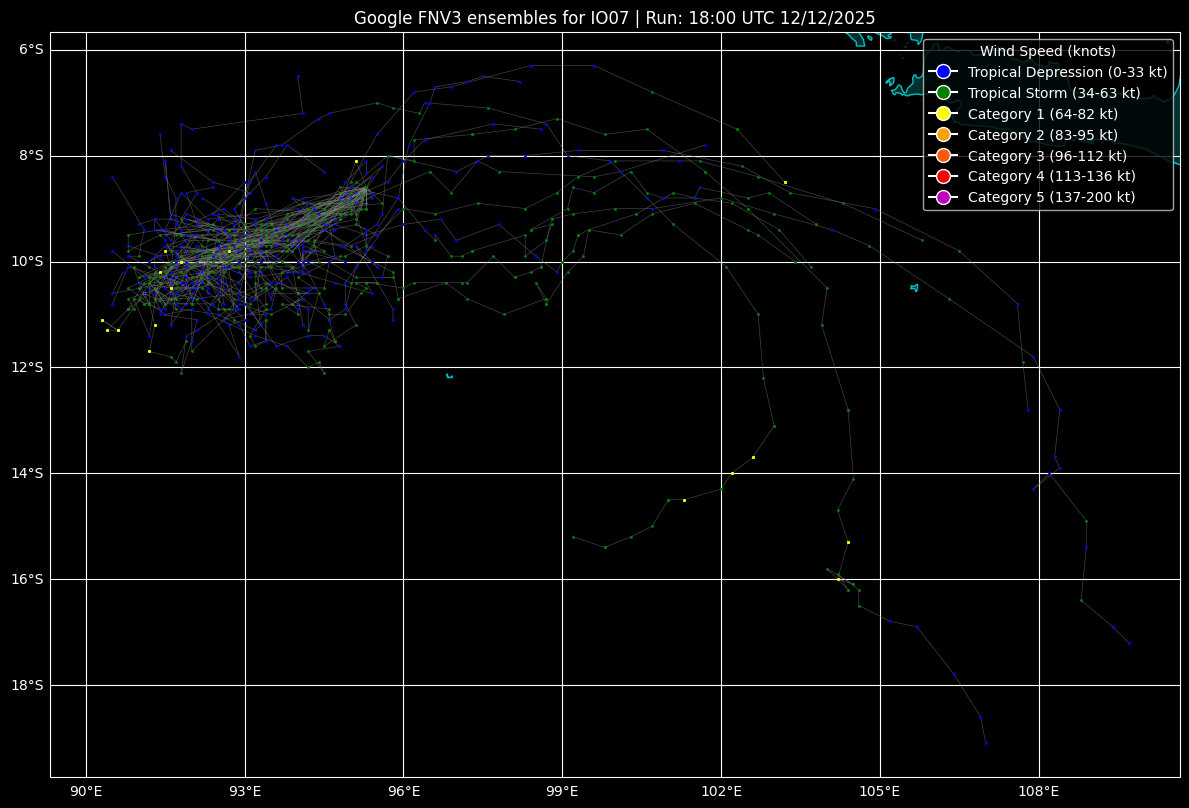

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature # Import cartopy.feature
import collections # To group data

# 1. Create a figure and an axes object with a Cartopy projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 2. Add standard Cartopy features
from matplotlib import colors
import matplotlib.style as mplstyle

mplstyle.use("dark_background")
ax.add_feature(cfeature.COASTLINE, linewidth=1, color="c")
ax.add_feature(cfeature.BORDERS, color="w", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor=colors.to_rgba("c", 0.25))

# Add gridlines
gridlines = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gridlines.top_labels = False
gridlines.right_labels = False

# Group data by ensemble identifier
ensemble_tracks = collections.defaultdict(list)
for dp in parsed_data:
    if dp['storm_basin'] != basin or dp['storm_number'] != btk_id:
        continue
    if dp['latitude'] is not None and dp['longitude'] is not None and dp['wind_speed'] is not None:
        ensemble_tracks[dp['ensemble_identifier']].append(dp)

print(f"Grouped {len(parsed_data)} data points into {len(ensemble_tracks)} ensembles.")

# Define wind speed categories and colors for plotting
wind_categories = {
    'Tropical Depression': (0, 33, 'b'),
    'Tropical Storm': (34, 63, 'g'),
    'Category 1': (64, 82, '#ffff00'),
    'Category 2': (83, 95, '#ffa001'),
    'Category 3': (96, 112, '#ff5908'),
    'Category 4': (113, 136, 'r'),
    'Category 5': (137, 200, 'm') # Upper bound can be adjusted
}

# Plot each ensemble track and scatter points
for ensemble_id, track_points in ensemble_tracks.items():
    lons = [p['longitude'] for p in track_points]
    lats = [p['latitude'] for p in track_points]
    wind_speeds = [p['wind_speed'] for p in track_points]

    # Plot the main track line (optional, but good for context)
    ax.plot(lons, lats, color='gray', linestyle='-', linewidth=0.5, transform=ccrs.PlateCarree(), alpha=0.5, label='_nolegend_')

    # Plot scatter points colored by wind speed
    for lon, lat, ws in zip(lons, lats, wind_speeds):
        color = 'black' # Default color if no category matches
        for category, (min_ws, max_ws, cat_color) in wind_categories.items():
            if min_ws <= ws <= max_ws:
                color = cat_color
                break
        ax.scatter(lon, lat, color=color, s=1, transform=ccrs.PlateCarree(), zorder=2)

# Add title and show plot
plt.title(f'Google FNV3 ensembles for {btk} | Run: {input_hour}:00 UTC {input_date}')

# Create a legend for wind intensity
legend_elements = []
for category, (min_ws, max_ws, cat_color) in wind_categories.items():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', label=f'{category} ({min_ws}-{max_ws} kt)',
                                      markerfacecolor=cat_color, markersize=10))

ax.legend(handles=legend_elements, title='Wind Speed (knots)')

plt.tight_layout()
plt.show()